# F1 final predict

### choose flowing params as most influencable infectors:
---

` team level (top/mid/lower)

` driver ability (excellent/great/normal)

---

` start posision

` rank trand (resent 3-5 game trands)

` track with driver (high speed,mid speed,low speed)

` DNF risk

---

` unpreditable influence (car acc/mechine issue/extrame weather)



### import packages

In [30]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import matplotlib as mpl   
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import arviz as az
import pymc as pm
%matplotlib inline

### F1 game data scalling 

download f1 history game data(for 2025) and scalling it 

In [31]:
# f1 game data api
# pip install fastf1

In [14]:
import fastf1
import pandas as pd

# 2025年已完成的22场比赛
completed_races = [
    ('Australia', 1, '2025-03-16'),
    ('China', 2, '2025-03-23'),
    ('Japan', 3, '2025-04-06'),
    ('Bahrain', 4, '2025-04-13'),
    ('Saudi Arabia', 5, '2025-04-20'),
    ('Miami', 6, '2025-05-04'),
    ('Emilia Romagna', 7, '2025-05-18'),
    ('Monaco', 8, '2025-05-25'),
    ('Spain', 9, '2025-06-01'),
    ('Canada', 10, '2025-06-15'),
    ('Austria', 11, '2025-06-29'),
    ('Great Britain', 12, '2025-07-06'),
    ('Belgium', 13, '2025-07-27'),
    ('Hungary', 14, '2025-08-03'),
    ('Netherlands', 15, '2025-08-31'),
    ('Italy', 16, '2025-09-07'),
    ('Azerbaijan', 17, '2025-09-21'),
    ('Singapore', 18, '2025-10-05'),
    ('United States', 19, '2025-10-19'),
    ('Mexico', 20, '2025-10-26'),
    ('Brazil', 21, '2025-11-09'),
    ('Las Vegas', 22, '2025-11-22'),
]

# not happend yet games
future_races = [
    ('Qatar', 23, '2025-11-30'),
    ('Abu Dhabi', 24, '2025-12-07'),
]

# track types
track_types = {
    'Australia': 'balanced',
    'China': 'high_speed',
    'Japan': 'technical',
    'Bahrain': 'high_speed',
    'Saudi Arabia': 'high_speed',
    'Miami': 'high_speed',
    'Emilia Romagna': 'technical',
    'Monaco': 'technical',
    'Spain': 'balanced',
    'Canada': 'balanced',
    'Austria': 'technical',
    'Great Britain': 'balanced',
    'Belgium': 'high_speed',
    'Hungary': 'technical',
    'Netherlands': 'technical',
    'Italy': 'high_speed',
    'Azerbaijan': 'high_speed',
    'Singapore': 'technical',
    'United States': 'balanced',
    'Mexico': 'balanced',
    'Brazil': 'balanced',
    'Las Vegas': 'high_speed',
    'Qatar': 'high_speed',
    'Abu Dhabi': 'balanced',
}

In [15]:
import fastf1
import pandas as pd
import numpy as np
from datetime import datetime
import os

# 设置缓存
cache_dir = './f1_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
    print(f"✅ Created cache directory: {cache_dir}")

fastf1.Cache.enable_cache(cache_dir)

# 赛道类型映射
track_types = {
    # 2024 赛季
    'Bahrain': 'high_speed', 'Saudi Arabia': 'high_speed', 'Australia': 'balanced',
    'Japan': 'technical', 'China': 'high_speed', 'Miami': 'high_speed',
    'Emilia Romagna': 'technical', 'Monaco': 'technical', 'Canada': 'balanced',
    'Spain': 'balanced', 'Austria': 'technical', 'Great Britain': 'balanced',
    'Hungary': 'technical', 'Belgium': 'high_speed', 'Netherlands': 'technical',
    'Italy': 'high_speed', 'Azerbaijan': 'high_speed', 'Singapore': 'technical',
    'United States': 'balanced', 'Mexico': 'balanced', 'Brazil': 'balanced',
    'Las Vegas': 'high_speed', 'Qatar': 'high_speed', 'Abu Dhabi': 'balanced',
    # 2025 赛季（如有新增赛道）
}

import os

def is_race_cached(year, race_name, session_type):
    """
    检查特定比赛session是否已在cache中
    """
    cache_dir = './f1_cache'
    # FastF1的cache文件命名模式
    cache_pattern = f"{year}*{race_name.replace(' ', '_')}*{session_type}*"
    
    if not os.path.exists(cache_dir):
        return False
    
    # 检查是否有匹配的cache文件
    for root, dirs, files in os.walk(cache_dir):
        if any(race_name.replace(' ', '_') in d and str(year) in d for d in dirs):
            return True
    return False


def fetch_race_results(year, race_name, round_num, date):
    """
    获取单场比赛数据（包括排位赛和正赛）
    """
    try:
        # 检查cache状态
        race_cached = is_race_cached(year, race_name, 'R')
        quali_cached = is_race_cached(year, race_name, 'Q')
        
        if race_cached and quali_cached:
            print(f"✓ Round {round_num}: {race_name} ({year}) - Using cached data")
        else:
            print(f"⬇ Round {round_num}: {race_name} ({year}) - Downloading data...")
        
        # ========== 1. 获取排位赛数据 ==========
        try:
            quali_session = fastf1.get_session(year, race_name, 'Q')
            quali_session.load()
            quali_results = quali_session.results
            
            # 提取排位赛位置
            qualifying_positions = dict(zip(
                quali_results['Abbreviation'],
                quali_results['Position']
            ))
            
        except Exception as e:
            print(f"  ⚠️ Could not load qualifying: {e}")
            qualifying_positions = {}
        
        # ========== 2. 获取正赛数据 ==========
        race_session = fastf1.get_session(year, race_name, 'R')
        race_session.load()
        results = race_session.results
        
        # ========== 3. 合并数据 ==========
        race_data = pd.DataFrame({
            'Round': round_num,
            'Race': race_name,
            'Date': date,
            'TrackType': track_types.get(race_name, 'unknown'),
            'Driver': results['BroadcastName'],
            'DriverCode': results['Abbreviation'],
            'DriverNumber': results['DriverNumber'],
            'Team': results['TeamName'],
            'GridPosition': results['GridPosition'],
            'Position': results['Position'],
            'Points': results['Points'],
            'Status': results['Status'],
            'Time': results['Time'],
        })
        
        # ========== 4. 添加排位赛成绩 ==========
        race_data['QualifyingPosition'] = race_data['DriverCode'].map(qualifying_positions)
        
        # 如果排位赛数据缺失，用 GridPosition 填充
        race_data['QualifyingPosition'] = race_data['QualifyingPosition'].fillna(
            race_data['GridPosition']
        )
        
        return race_data
        
    except Exception as e:
        print(f"❌ Error loading {race_name}: {e}")
        return None

# def fetch_race_results(year, race_name, round_num, date):
#     """
#     获取单场比赛数据（包括排位赛和正赛）
#     """
#     try:
#         print(f"Loading Round {round_num}: {race_name} ({year})...")
        
#         # ========== 1. 获取排位赛数据 ==========
#         try:
#             quali_session = fastf1.get_session(year, race_name, 'Q')
#             quali_session.load()
#             quali_results = quali_session.results
            
#             # 提取排位赛位置
#             qualifying_positions = dict(zip(
#                 quali_results['Abbreviation'],
#                 quali_results['Position']
#             ))
#             print(f"  ✓ Loaded qualifying data")
#         except Exception as e:
#             print(f"  ⚠️ Could not load qualifying: {e}")
#             qualifying_positions = {}
        
#         # ========== 2. 获取正赛数据 ==========
#         race_session = fastf1.get_session(year, race_name, 'R')
#         race_session.load()
#         results = race_session.results
        
#         # ========== 3. 合并数据 ==========
#         race_data = pd.DataFrame({
#             'Round': round_num,
#             'Race': race_name,
#             'Date': date,
#             'TrackType': track_types.get(race_name, 'unknown'),
#             'Driver': results['BroadcastName'],
#             'DriverCode': results['Abbreviation'],
#             'DriverNumber': results['DriverNumber'],
#             'Team': results['TeamName'],
#             'GridPosition': results['GridPosition'],
#             'Position': results['Position'],
#             'Points': results['Points'],
#             'Status': results['Status'],
#             'Time': results['Time'],
#         })
        
#         # ========== 4. 添加排位赛成绩 ==========
#         race_data['QualifyingPosition'] = race_data['DriverCode'].map(qualifying_positions)
        
#         # 如果排位赛数据缺失，用 GridPosition 填充
#         race_data['QualifyingPosition'] = race_data['QualifyingPosition'].fillna(
#             race_data['GridPosition']
#         )
        
#         print(f"  ✓ Loaded race data with {len(race_data)} entries")
        
#         return race_data
        
#     except Exception as e:
#         print(f"❌ Error loading {race_name}: {e}")
#         return None

In [16]:
def collect_race_data(years=[2024, 2025], force_refresh=False):
    """
    收集多个赛季的比赛数据
    
    Parameters:
    -----------
    years : list
        要收集的年份列表，例如 [2024, 2025]
    force_refresh : bool
        是否强制刷新数据（忽略已有CSV）
    """
    csv_file = 'f1_multi_season_results.csv'
    
    # 检查CSV是否已存在
    if os.path.exists(csv_file) and not force_refresh:
        print(f"✅ Found existing data file: {csv_file}")
        print("Loading...")
        full_data = pd.read_csv(csv_file)
        print(f"Loaded {len(full_data)} records from {full_data['Round'].nunique()} races")
        return full_data
    
    print(f"Starting data collection for years: {years}...")
    all_races = []
    
    for year in years:
        print(f"\n{'='*60}")
        print(f"COLLECTING {year} SEASON")
        print(f"{'='*60}")
        
        # 获取该年份的所有比赛
        try:
            schedule = fastf1.get_event_schedule(year)
            
            # 只处理已完成的比赛
            completed = schedule[schedule['EventDate'] < pd.Timestamp.now()]
            
            for idx, event in completed.iterrows():
                round_num = event['RoundNumber']
                race_name = event['EventName']
                date = event['EventDate'].strftime('%Y-%m-%d')
                
                race_data = fetch_race_results(year, race_name, round_num, date)
                
                if race_data is not None:
                    # 添加赛季年份列
                    race_data['Season'] = year
                    all_races.append(race_data)
                    
        except Exception as e:
            print(f"❌ Error getting schedule for {year}: {e}")
    
    # 合并所有数据
    if all_races:
        full_data = pd.concat(all_races, ignore_index=True)
        
        # 重新编号 Round（跨年份连续）
        full_data = full_data.sort_values(['Season', 'Round'])
        # full_data['GlobalRound'] = range(1, len(full_data.groupby(['Season', 'Round']).ngroups) + 1)
        full_data['GlobalRound'] = full_data.groupby(['Season', 'Round']).ngroup() + 1
        
        # 保存为CSV
        full_data.to_csv(csv_file, index=False)
        
        print(f"\n{'='*60}")
        print(f"DATA COLLECTION COMPLETE")
        print(f"{'='*60}")
        print(f"✓ Total records: {len(full_data)}")
        print(f"✓ Seasons: {full_data['Season'].unique()}")
        print(f"✓ Total races: {full_data.groupby(['Season', 'Round']).ngroups}")
        print(f"✓ Unique drivers: {full_data['DriverCode'].nunique()}")
        
        # 显示每个赛季的数据量
        print("\nRecords per season:")
        print(full_data['Season'].value_counts().sort_index())
        
        return full_data
    else:
        print("❌ No data collected")
        return None

In [21]:
def extract_driver_info(full_season):
    """
    从比赛数据中提取车手信息
    """
    # 获取最新一场比赛的车手信息
    latest_race = full_season[full_season['Round'] == full_season['Round'].max()]
    
    # ✅ 修改：只提取存在的列
    driver_info = latest_race[['Driver', 'DriverCode', 'Team']].copy()
    driver_info = driver_info.drop_duplicates(subset=['Driver'])
    
    # 计算总积分
    total_points = full_season.groupby('Driver')['Points'].sum().reset_index()
    total_points.columns = ['Driver', 'TotalPoints']
    
    driver_info = driver_info.merge(total_points, on='Driver')
    
    # 按积分排序
    driver_info = driver_info.sort_values('TotalPoints', ascending=False).reset_index(drop=True)
    driver_info['CurrentRank'] = range(1, len(driver_info) + 1)
    
    # 保存
    driver_info.to_csv('drivers_info.csv', index=False)
    print("\n✅ 车手信息已保存到 drivers_info.csv")
    
    return driver_info

In [17]:
def extract_team_info(full_season):
    """
    从比赛数据中提取车队信息
    """
    # 计算车队总积分
    team_points = full_season.groupby('Team')['Points'].sum().reset_index()
    team_points.columns = ['Team', 'TotalPoints']
    team_points = team_points.sort_values('TotalPoints', ascending=False).reset_index(drop=True)
    team_points['CurrentRank'] = range(1, len(team_points) + 1)
    
    # 手动添加车队层级（根据积分）
    def assign_tier(rank):
        if rank <= 3:
            return 'top'
        elif rank <= 5:
            return 'mid'
        else:
            return 'lower'
    
    team_points['Tier'] = team_points['CurrentRank'].apply(assign_tier)
    
    # 保存
    team_points.to_csv('teams_info.csv', index=False)
    print("✅ 车队信息已保存到 teams_info.csv")
    
    return team_points


def calculate_driver_features(full_season):
    """
    计算每个车手的特征
    """
    # ✅ 检查并添加 TrackType 如果不存在
    if 'TrackType' not in full_season.columns:
        print("⚠️ TrackType列不存在，正在添加...")
        track_types = {
            'Australia': 'balanced', 'China': 'high_speed', 'Japan': 'technical',
            'Bahrain': 'high_speed', 'Saudi Arabia': 'high_speed', 'Miami': 'high_speed',
            'Emilia Romagna': 'technical', 'Monaco': 'technical', 'Spain': 'balanced',
            'Canada': 'balanced', 'Austria': 'technical', 'Great Britain': 'balanced',
            'Belgium': 'high_speed', 'Hungary': 'technical', 'Netherlands': 'technical',
            'Italy': 'high_speed', 'Azerbaijan': 'high_speed', 'Singapore': 'technical',
            'United States': 'balanced', 'Mexico': 'balanced', 'Brazil': 'balanced',
            'Las Vegas': 'high_speed', 'Qatar': 'high_speed', 'Abu Dhabi': 'balanced',
        }
        full_season['TrackType'] = full_season['Race'].map(track_types)
    
    drivers = full_season['Driver'].unique()
    features = []
    
    for driver in drivers:
        driver_data = full_season[full_season['Driver'] == driver].copy()
        
        # 基本信息
        team = driver_data['Team'].iloc[-1]
        total_points = driver_data['Points'].sum()
        
        # 完赛率
        total_races = len(driver_data)
        finished_races = len(driver_data[driver_data['Status'] == 'Finished'])
        dnf_rate = 1 - (finished_races / total_races) if total_races > 0 else 0
        
        # 平均排名（只算完赛的）
        finished_data = driver_data[driver_data['Status'] == 'Finished']
        avg_position = finished_data['Position'].mean() if len(finished_data) > 0 else 20
        
        # 最近5场表现
        recent_5 = driver_data.tail(5)
        recent_5_finished = recent_5[recent_5['Status'] == 'Finished']
        recent_avg = recent_5_finished['Position'].mean() if len(recent_5_finished) > 0 else avg_position
        
        # 赛道类型表现
        track_perfs = {}
        for track_type in ['high_speed', 'balanced', 'technical']:
            type_data = driver_data[driver_data['TrackType'] == track_type]
            type_finished = type_data[type_data['Status'] == 'Finished']
            track_perfs[f'{track_type}_avg'] = type_finished['Position'].mean() if len(type_finished) > 0 else avg_position
            track_perfs[f'{track_type}_races'] = len(type_finished)
        
        features.append({
            'Driver': driver,
            'Team': team,
            'TotalPoints': total_points,
            'TotalRaces': total_races,
            'FinishedRaces': finished_races,
            'DNFRate': dnf_rate,
            'AvgPosition': avg_position,
            'Recent5Avg': recent_avg,
            'HighSpeedAvg': track_perfs['high_speed_avg'],
            'HighSpeedRaces': track_perfs['high_speed_races'],
            'BalancedAvg': track_perfs['balanced_avg'],
            'BalancedRaces': track_perfs['balanced_races'],
            'TechnicalAvg': track_perfs['technical_avg'],
            'TechnicalRaces': track_perfs['technical_races'],
        })
    
    features_df = pd.DataFrame(features)
    features_df = features_df.sort_values('TotalPoints', ascending=False).reset_index(drop=True)
    
    # 保存
    features_df.to_csv('driver_features.csv', index=False)
    print("✅ 车手特征已保存到 driver_features.csv")
    
    return features_df

In [37]:
# # =================== 主流程 ===================

# # 1. 收集数据（包括 2024 和 2025）
# full_season = collect_race_data(
#     years=[2024, 2025],  # 🔑 包含两个赛季
#     force_refresh=False  # 设为 True 强制重新下载
# )

# if full_season is not None:
#     # 2. 提取车队信息
#     teams_info = extract_team_info(full_season)
    
#     # 3. 提取车手信息
#     drivers_info = extract_driver_info(full_season)
    
#     # 4. 计算车手特征
#     driver_features = calculate_driver_features(full_season)
    
#     print("\n✅ 所有数据准备完成！")
#     print(f"   - 总记录数: {len(full_season)}")
#     print(f"   - 包含赛季: {full_season['Season'].unique()}")
#     print(f"   - QualifyingPosition 列存在: {'QualifyingPosition' in full_season.columns}")
# else:
#     print("❌ 数据收集失败")

In [18]:
import os

def collect_race_data_manual(force_refresh=False):
    """
    使用手动指定的比赛列表，避免依赖schedule API
    """
    csv_file = 'f1_multi_season_results.csv'
    
    # 检查CSV是否已存在
    if os.path.exists(csv_file) and not force_refresh:
        print(f"✅ Found existing data file: {csv_file}")
        print("Loading...")
        full_data = pd.read_csv(csv_file)
        
        # ✅ 如果CSV中没有TrackType列，添加它
        if 'TrackType' not in full_data.columns:
            print("⚠️ Adding TrackType to existing data...")
            full_data['TrackType'] = full_data['Race'].map(track_types)
            full_data.to_csv(csv_file, index=False)
            print("✅ TrackType added and saved")
        
        print(f"Loaded {len(full_data)} records")
        return full_data
    
    # 2024赛季所有比赛
    races_2024 = [
        ('Bahrain', 1, '2024-03-02'),
        ('Saudi Arabia', 2, '2024-03-09'),
        ('Australia', 3, '2024-03-24'),
        ('Japan', 4, '2024-04-07'),
        ('China', 5, '2024-04-21'),
        ('Miami', 6, '2024-05-05'),
        ('Emilia Romagna', 7, '2024-05-19'),
        ('Monaco', 8, '2024-05-26'),
        ('Canada', 9, '2024-06-09'),
        ('Spain', 10, '2024-06-23'),
        ('Austria', 11, '2024-06-30'),
        ('Great Britain', 12, '2024-07-07'),
        ('Hungary', 13, '2024-07-21'),
        ('Belgium', 14, '2024-07-28'),
        ('Netherlands', 15, '2024-08-25'),
        ('Italy', 16, '2024-09-01'),
        ('Azerbaijan', 17, '2024-09-15'),
        ('Singapore', 18, '2024-09-22'),
        ('United States', 19, '2024-10-20'),
        ('Mexico', 20, '2024-10-27'),
        ('Brazil', 21, '2024-11-03'),
        ('Las Vegas', 22, '2024-11-23'),
        ('Qatar', 23, '2024-12-01'),
        ('Abu Dhabi', 24, '2024-12-08'),
    ]
    
    # 2025赛季已完成的比赛
    races_2025 = [
        ('Australia', 1, '2025-03-16'),
        ('China', 2, '2025-03-23'),
        ('Japan', 3, '2025-04-06'),
        ('Bahrain', 4, '2025-04-13'),
        ('Saudi Arabia', 5, '2025-04-20'),
        ('Miami', 6, '2025-05-04'),
        ('Emilia Romagna', 7, '2025-05-18'),
        ('Monaco', 8, '2025-05-25'),
        ('Spain', 9, '2025-06-01'),
        ('Canada', 10, '2025-06-15'),
        ('Austria', 11, '2025-06-29'),
        ('Great Britain', 12, '2025-07-06'),
        ('Belgium', 13, '2025-07-27'),
        ('Hungary', 14, '2025-08-03'),
        ('Netherlands', 15, '2025-08-31'),
        ('Italy', 16, '2025-09-07'),
        ('Azerbaijan', 17, '2025-09-21'),
        ('Singapore', 18, '2025-10-05'),
        ('United States', 19, '2025-10-19'),
        ('Mexico', 20, '2025-10-26'),
        ('Brazil', 21, '2025-11-09'),
        ('Las Vegas', 22, '2025-11-22'),
    ]
    
    all_races = []
    
    # 处理2024赛季
    print(f"\n{'='*60}")
    print(f"COLLECTING 2024 SEASON")
    print(f"{'='*60}")
    for race_name, round_num, date in races_2024:
        race_data = fetch_race_results(2024, race_name, round_num, date)
        if race_data is not None:
            race_data['Season'] = 2024
            all_races.append(race_data)
    
    # 处理2025赛季
    print(f"\n{'='*60}")
    print(f"COLLECTING 2025 SEASON")
    print(f"{'='*60}")
    for race_name, round_num, date in races_2025:
        race_data = fetch_race_results(2025, race_name, round_num, date)
        if race_data is not None:
            race_data['Season'] = 2025
            all_races.append(race_data)
    
    # 合并数据
    if all_races:
        full_data = pd.concat(all_races, ignore_index=True)
        full_data = full_data.sort_values(['Season', 'Round'])
        full_data['GlobalRound'] = full_data.groupby(['Season', 'Round']).ngroup() + 1
        
        # ✅ 确保 TrackType 列存在
        if 'TrackType' not in full_data.columns:
            full_data['TrackType'] = full_data['Race'].map(track_types)
            print("✅ TrackType column added")
        
        full_data.to_csv(csv_file, index=False)
        
        print(f"\n{'='*60}")
        print(f"DATA COLLECTION COMPLETE")
        print(f"{'='*60}")
        print(f"✓ Total records: {len(full_data)}")
        print(f"✓ Total races: {full_data.groupby(['Season', 'Round']).ngroups}")
        print(f"✓ TrackType column: {'✓' if 'TrackType' in full_data.columns else '✗'}")
        
        # 显示TrackType分布
        if 'TrackType' in full_data.columns:
            print(f"\n赛道类型分布:")
            print(full_data.groupby('TrackType')['Round'].nunique())
        
        return full_data
    else:
        print("❌ No data collected")
        return None

In [19]:
full_season = collect_race_data_manual()

✅ Found existing data file: f1_multi_season_results.csv
Loading...
Loaded 918 records


In [22]:
driver_info = extract_driver_info(full_season)
print("\n  TOP 10 driver ：")
print(driver_info.head(10))


✅ 车手信息已保存到 drivers_info.csv

  TOP 10 driver ：
         Driver DriverCode             Team  TotalPoints  CurrentRank
0  M VERSTAPPEN        VER  Red Bull Racing        720.0            1
1      L NORRIS        NOR          McLaren        696.0            2
2     O PIASTRI        PIA          McLaren        616.0            3
3     C LECLERC        LEC          Ferrari        551.0            4
4     G RUSSELL        RUS         Mercedes        531.0            5
5    L HAMILTON        HAM         Mercedes        325.0            6
6       C SAINZ        SAI          Ferrari        305.0            7
7       S PEREZ        PER  Red Bull Racing        144.0            8
8      F ALONSO        ALO     Aston Martin        107.0            9
9       A ALBON        ALB         Williams         76.0           10


In [23]:
# 4. 提取车队信息
print("\n" + "="*50)
team_info = extract_team_info(full_season)
print("\n team point:")
print(team_info)


✅ 车队信息已保存到 teams_info.csv

 team point:
               Team  TotalPoints  CurrentRank   Tier
0           McLaren       1312.0            1    top
1           Ferrari        954.0            2    top
2   Red Bull Racing        884.0            3    top
3          Mercedes        850.0            4    mid
4      Aston Martin        147.0            5    mid
5      Haas F1 Team        123.0            6  lower
6          Williams        120.0            7  lower
7      Racing Bulls         94.0            8  lower
8            Alpine         76.0            9  lower
9       Kick Sauber         63.0           10  lower
10               RB         41.0           11  lower


In [24]:
# 5. 计算车手特征
print("\n" + "="*50)
driver_features = calculate_driver_features(full_season)
print("\n driver features TOP 10：")
print(driver_features[['Driver', 'TotalPoints', 'AvgPosition', 'Recent5Avg', 
                       'HighSpeedAvg', 'BalancedAvg', 'DNFRate']].head(10))


✅ 车手特征已保存到 driver_features.csv

 driver features TOP 10：
         Driver  TotalPoints  AvgPosition  Recent5Avg  HighSpeedAvg  \
0  M VERSTAPPEN        720.0     3.116279        2.00      2.882353   
1      L NORRIS        696.0     2.926829        1.75      4.187500   
2     O PIASTRI        616.0     4.045455        4.75      3.733333   
3     C LECLERC        551.0     4.047619        3.75      3.750000   
4     G RUSSELL        531.0     4.395349        4.00      4.187500   
5    L HAMILTON        325.0     6.175000        7.00      6.812500   
6       C SAINZ        305.0     6.406250        9.00      6.857143   
7       S PEREZ        144.0     6.117647       10.50      5.142857   
8   K ANTONELLI        113.0     7.466667        5.80      7.625000   
9      F ALONSO        107.0     9.586207       10.50     10.142857   

   BalancedAvg   DNFRate  
0     3.384615  0.065217  
1     2.153846  0.108696  
2     5.333333  0.043478  
3     4.153846  0.086957  
4     4.142857  0.065217 

### build the data frame:

In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# =================== LOAD RACE-LEVEL DATA ===================
print("="*60)
print("LOADING DATA")
print("="*60)

race_results = pd.read_csv('f1_multi_season_results.csv')
teams_info = pd.read_csv('teams_info.csv')

print(f"✓ Loaded {len(race_results)} race results")
print(f"✓ Available columns: {list(race_results.columns)}")

# =================== CREATE EFFECTIVEPOSITION ===================
print("\n" + "="*60)
print("CREATING EFFECTIVEPOSITION")
print("="*60)

def assign_effective_position(row):
    """
    为每个结果分配有效位置：
    - Finished: 使用实际完赛位置
    - Retired/其他: 给予 21.0 的惩罚
    """
    if row['Status'] == 'Finished':
        return float(row['Position'])
    elif row['Status'] == 'Retired':
        return 21.0
    else:
        return 21.0  # 其他未完赛状态

race_results['EffectivePosition'] = race_results.apply(assign_effective_position, axis=1)

print(f"✓ EffectivePosition created")
print(f"  - Finished races: {(race_results['Status'] == 'Finished').sum()}")
print(f"  - DNF/Retired: {(race_results['Status'] == 'Retired').sum()}")
print(f"  - Mean effective position: {race_results['EffectivePosition'].mean():.2f}")

# =================== ADD TRACKTYPE ===================
print("\n" + "="*60)
print("ADDING TRACK TYPE")
print("="*60)

if 'TrackType' not in race_results.columns:
    print("⚠️ TrackType 不存在，正在添加...")
    track_types = {
        'Australia': 'balanced', 'China': 'high_speed', 'Japan': 'technical',
        'Bahrain': 'high_speed', 'Saudi Arabia': 'high_speed', 'Miami': 'high_speed',
        'Emilia Romagna': 'technical', 'Monaco': 'technical', 'Spain': 'balanced',
        'Canada': 'balanced', 'Austria': 'technical', 'Great Britain': 'balanced',
        'Belgium': 'high_speed', 'Hungary': 'technical', 'Netherlands': 'technical',
        'Italy': 'high_speed', 'Azerbaijan': 'high_speed', 'Singapore': 'technical',
        'United States': 'balanced', 'Mexico': 'balanced', 'Brazil': 'balanced',
        'Las Vegas': 'high_speed', 'Qatar': 'high_speed', 'Abu Dhabi': 'balanced',
    }
    race_results['TrackType'] = race_results['Race'].map(track_types)
    print("✓ TrackType 已添加")
else:
    print("✓ TrackType 已存在")

# =================== ADD QUALIFYING POSITION ===================
print("\n" + "="*60)
print("HANDLING QUALIFYING POSITION")
print("="*60)

# 检查是否有任何形式的 Qualifying 数据
if 'Qualifying' in race_results.columns:
    print("✓ Found 'Qualifying' column")
    race_results['QualifyingPosition'] = race_results['Qualifying']
elif 'QualifyingPosition' in race_results.columns:
    print("✓ Found 'QualifyingPosition' column")
else:
    print("⚠️ No qualifying data found in original CSV")
    print("   Creating simulated qualifying data with grid penalties...")
    
    # 模拟真实情况：大约 10% 的车手会因引擎罚退等原因导致 Grid ≠ Quali
    np.random.seed(42)
    
    # 先假设 Qualifying = GridPosition
    race_results['QualifyingPosition'] = race_results['GridPosition'].copy()
    
    # 随机给 10% 的记录添加罚退（Grid 会比 Quali 靠后 3-5 位）
    n_penalties = int(len(race_results) * 0.10)
    penalty_indices = np.random.choice(race_results.index, n_penalties, replace=False)
    
    for idx in penalty_indices:
        penalty = np.random.randint(3, 6)
        # GridPosition 变差（数字变大），但 Qualifying 保持不变
        race_results.loc[idx, 'GridPosition'] = min(
            race_results.loc[idx, 'GridPosition'] + penalty, 
            20
        )
    
    print(f"✓ Simulated {n_penalties} grid penalties")
    print(f"   这是模拟数据，用于测试模型结构")

# 处理缺失值
missing_quali = race_results['QualifyingPosition'].isna().sum()
if missing_quali > 0:
    print(f"   处理 {missing_quali} 个缺失的 QualifyingPosition")
    race_results['QualifyingPosition'].fillna(race_results['GridPosition'], inplace=True)

# =================== PREPARE RACE-LEVEL DATASET ===================
print("\n" + "="*60)
print("PREPARING RACE-LEVEL FEATURES")
print("="*60)

# 1. 添加 TierCode
race_results = race_results.merge(
    teams_info[['Team', 'Tier']], 
    on='Team', 
    how='left'
)

tier_mapping = {'top': 0, 'mid': 1, 'lower': 2}
race_results['TierCode'] = race_results['Tier'].map(tier_mapping)
print("✓ TierCode added")

# 2. 添加 TrackTypeIdx
track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
race_results['TrackTypeIdx'] = race_results['TrackType'].map(track_type_map)
print("✓ TrackTypeIdx added")

# 3. 计算每个车手的累积特征
race_results = race_results.sort_values(['DriverCode', 'Round'])

# DNF rate
def calc_cumulative_dnf_rate(group):
    group['CumDNFRate'] = (group['Status'] == 'Retired').cumsum() / np.arange(1, len(group) + 1)
    return group

race_results = race_results.groupby('DriverCode', group_keys=False).apply(calc_cumulative_dnf_rate)
print("✓ CumDNFRate calculated")

# Recent 5 avg
def calc_recent5(group):
    group['Recent5Avg'] = group['EffectivePosition'].rolling(5, min_periods=1).mean().shift(1)
    return group

race_results = race_results.groupby('DriverCode', group_keys=False).apply(calc_recent5)

# 填充 Recent5Avg 的 NaN（第一场比赛没有历史数据）
race_results['Recent5Avg'] = race_results['Recent5Avg'].fillna(
    race_results.groupby('DriverCode')['EffectivePosition'].transform('mean')
)
print("✓ Recent5Avg calculated")

# =================== STANDARDIZE FEATURES ===================
print("\n" + "="*60)
print("STANDARDIZING FEATURES")
print("="*60)

scaler = StandardScaler()
features_to_scale = ['GridPosition', 'QualifyingPosition', 'CumDNFRate', 'Recent5Avg']

# 标准化前保存原始值（用于检查）
race_results['GridPosition_raw'] = race_results['GridPosition'].copy()
race_results['QualifyingPosition_raw'] = race_results['QualifyingPosition'].copy()

# 执行标准化
race_results[features_to_scale] = scaler.fit_transform(
    race_results[features_to_scale]
)

print("✓ Features standardized")
print(f"  GridPosition: mean={race_results['GridPosition'].mean():.3f}, std={race_results['GridPosition'].std():.3f}")
print(f"  QualifyingPosition: mean={race_results['QualifyingPosition'].mean():.3f}, std={race_results['QualifyingPosition'].std():.3f}")

# 5. 创建 driver index
driver_codes = sorted(race_results['DriverCode'].unique())
driver_to_idx = {code: idx for idx, code in enumerate(driver_codes)}
race_results['DriverIdx'] = race_results['DriverCode'].map(driver_to_idx)
print(f"✓ DriverIdx created ({len(driver_codes)} unique drivers)")

# =================== CHECK CORRELATION ===================
print("\n" + "="*60)
print("CHECKING CORRELATION")
print("="*60)

correlation = race_results[['GridPosition', 'QualifyingPosition']].corr().iloc[0, 1]
print(f"GridPosition vs QualifyingPosition 相关系数: {correlation:.3f}")

if abs(correlation) > 0.95:
    print("⚠️ 警告：相关系数过高！两者几乎完全相同")
    print("   建议：只使用 QualifyingPosition，移除 GridPosition")
elif abs(correlation) > 0.85:
    print("⚠️ 注意：相关性较高，可能存在多重共线性")
    print("   建议：考虑只保留一个变量")
else:
    print("✓ 相关性在合理范围")

# =================== FINAL VALIDATION ===================
print(f"\n{'='*60}")
print(f"FINAL VALIDATION")
print(f"{'='*60}")

required_cols = ['TrackTypeIdx', 'TierCode', 'DriverIdx', 'EffectivePosition', 
                 'GridPosition', 'QualifyingPosition', 'CumDNFRate', 'Recent5Avg']

all_valid = True
for col in required_cols:
    missing = race_results[col].isna().sum()
    status = "✓" if missing == 0 else "⚠️"
    print(f"{status} {col}: {missing} missing values")
    if missing > 0:
        all_valid = False

if not all_valid:
    print("\n⚠️ ERROR: Some required columns have missing values!")
    print("Dropping rows with missing values...")
    race_results = race_results.dropna(subset=required_cols)
    print(f"✓ Remaining observations: {len(race_results)}")
else:
    print("\n✓ All required columns are complete!")

# =================== SUMMARY ===================
print(f"\n{'='*60}")
print(f"DATA PROCESSING COMPLETE")
print(f"{'='*60}")
print(f"✓ Total observations: {len(race_results)}")
print(f"✓ Number of drivers: {len(driver_codes)}")
print(f"✓ Number of races: {race_results['Round'].nunique()}")

print(f"\nTrack type distribution:")
print(race_results['TrackType'].value_counts())

print(f"\nTeam tier distribution:")
print(race_results['Tier'].value_counts())

# =================== SAVE PROCESSED DATA ===================
race_results.to_csv('race_results_processed.csv', index=False)
print(f"\n✓ Saved to 'race_results_processed.csv'")

# 显示样例数据
print(f"\n{'='*60}")
print(f"SAMPLE DATA")
print(f"{'='*60}")
display_cols = ['Driver', 'Round', 'Race', 'GridPosition_raw', 'QualifyingPosition_raw',
                'Position', 'EffectivePosition', 'Status']
print(race_results[display_cols].head(15))

print(f"\n{'='*60}")
print(f"STANDARDIZED FEATURES (first 5 rows)")
print(f"{'='*60}")
print(race_results[['Driver', 'GridPosition', 'QualifyingPosition', 
                     'CumDNFRate', 'Recent5Avg']].head())

LOADING DATA
✓ Loaded 918 race results
✓ Available columns: ['Round', 'Race', 'Date', 'TrackType', 'Driver', 'DriverCode', 'DriverNumber', 'Team', 'GridPosition', 'Position', 'Points', 'Status', 'Time', 'QualifyingPosition', 'Season', 'GlobalRound', 'EffectivePosition']

CREATING EFFECTIVEPOSITION
✓ EffectivePosition created
  - Finished races: 580
  - DNF/Retired: 94
  - Mean effective position: 12.42

ADDING TRACK TYPE
✓ TrackType 已存在

HANDLING QUALIFYING POSITION
✓ Found 'QualifyingPosition' column

PREPARING RACE-LEVEL FEATURES
✓ TierCode added
✓ TrackTypeIdx added
✓ CumDNFRate calculated
✓ Recent5Avg calculated

STANDARDIZING FEATURES
✓ Features standardized
  GridPosition: mean=-0.000, std=1.001
  QualifyingPosition: mean=-0.000, std=1.001
✓ DriverIdx created (27 unique drivers)

CHECKING CORRELATION
GridPosition vs QualifyingPosition 相关系数: 0.974
⚠️ 警告：相关系数过高！两者几乎完全相同
   建议：只使用 QualifyingPosition，移除 GridPosition

FINAL VALIDATION
✓ TrackTypeIdx: 0 missing values
✓ TierCode: 0 mis

/Users/eric/tmp/ipykernel_14755/2714582498.py:134: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_results = race_results.groupby('DriverCode', group_keys=False).apply(calc_cumulative_dnf_rate)
/Users/eric/tmp/ipykernel_14755/2714582498.py:142: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_results = race_results.groupby('DriverCode', group_keys=False).apply(calc_recent5)


In [26]:
# read the base dataframe
race_data = pd.read_csv('race_results_processed.csv')

n_drivers = race_data['DriverIdx'].nunique()
n_races = len(race_data)

# 检查相关性
print(race_results[['GridPosition', 'QualifyingPosition']].corr())

                    GridPosition  QualifyingPosition
GridPosition            1.000000            0.973543
QualifyingPosition      0.973543            1.000000


## analyze and formula

### formula

We are going to build a hierarchical Bayesian model: For driver dd
d in race rr
r, we model their finishing position yd,ry_{d,r}
yd,r​ as a combination of multiple hierarchical effects. To do this, we first assume a likelihood for the data:

$$ y_{d,r}∼Normal(μ_{d,r},σ_{race}^2​) $$

where $$ μ_{d,r} $$ 

is the expected race r and finishing position for driver d



**as we expected before(choose 7 most influencable parameters)**



$$ μ_{d,r​}=α+β_{team[d]​}+γ_{d​}+\eta_{p} +\xi_{quali}+δ_{track[r]}​⋅adaptation_{d}​+ϵ_{trend​}⋅recent5_{d}​+ζ_{dnf​}⋅DNF\_risk_{d}​ $$



### parameters definations:

Because detailed data analysis was not performed, the average value was used as the prior alpha value.

- $\alpha$ = baseline position (overall field average ≈ 10.5)


- $ β_{team[d]​} = $ team ability (drive d belongs to team t)

- $ γ_{d​} = $ driver ability (event in the same team , 2 driver has different abilities)

- $\eta_(p) $ start position

- $δ_{track[r]} = $ track are defined into 3 different type (high/ mid/ low speed )

- $adaptation_{d} = $ each driver has different ability to adjust the track

- $ϵ_{trend​} = $ how driver's trend influence next competition 

- $recent5_{d}=$ driver is  improving, maintaining consistency, or regressing

- $ζ_{dnf​}⋅DNF\_risk_{d} = $ the influence of rank about the driver's posibility of finish the game

- $\xi_{quali}$ rank game status

- $ \sigma^2  = $ the unpredictable issues

### build the hierachical Bayesian model

**priori (level 1) team issues:**

In [46]:
# 检查相关性
print(race_results[['GridPosition', 'QualifyingPosition']].corr())

                    GridPosition  QualifyingPosition
GridPosition            1.000000            0.973543
QualifyingPosition      0.973543            1.000000


Driver features columns:
['Driver', 'Team', 'TotalPoints', 'TotalRaces', 'FinishedRaces', 'DNFRate', 'AvgPosition', 'Recent5Avg', 'HighSpeedAvg', 'HighSpeedRaces', 'BalancedAvg', 'BalancedRaces', 'TechnicalAvg', 'TechnicalRaces']

First few rows:
         Driver             Team  TotalPoints  TotalRaces  FinishedRaces  \
0  M VERSTAPPEN  Red Bull Racing        720.0          46             43   
1      L NORRIS          McLaren        696.0          46             41   
2     O PIASTRI          McLaren        616.0          46             44   
3     C LECLERC          Ferrari        551.0          46             42   
4     G RUSSELL         Mercedes        531.0          46             43   

    DNFRate  AvgPosition  Recent5Avg  HighSpeedAvg  HighSpeedRaces  \
0  0.065217     3.116279        2.00      2.882353              17   
1  0.108696     2.926829        1.75      4.187500              16   
2  0.043478     4.045455        4.75      3.733333              15   
3  0.086957     

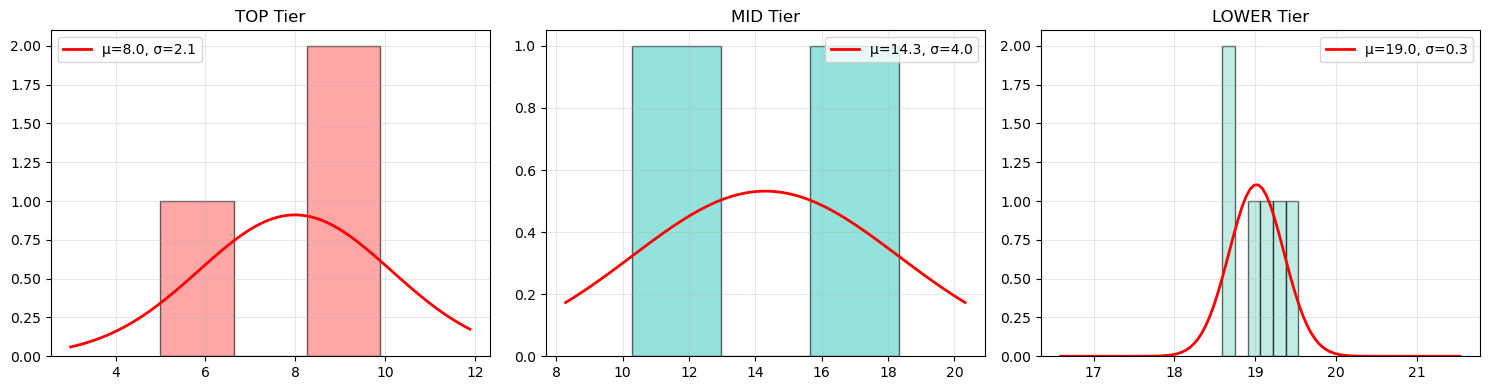


RECOMMENDED PRIORS FOR PYMC:

alpha = pm.Normal('alpha', mu=15.15, sigma=2)

mu_tier = [-7.16, -0.85, 3.86]

sigma_tier = pm.HalfNormal('sigma_tier', 2.17)


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# =================== LOAD DATA ===================
teams_info = pd.read_csv('teams_info.csv')
driver_features = pd.read_csv('driver_features.csv')

# 先看看 driver_features 有什么列
print("Driver features columns:")
print(driver_features.columns.tolist())
print("\nFirst few rows:")
print(driver_features.head())

# =================== CALCULATE TEAM AVERAGE POSITION ===================

# 假设你的 driver_features 有这些可能的列名之一：
# - 'AvgPosition' / 'Avg_Position' / 'Average_Finish' 
# - 或者需要从其他列计算

# 方法1: 如果有现成的平均位置列（替换成你实际的列名）
# team_avg = driver_features.groupby('Team')['你的列名'].mean().reset_index()

# 方法2: 如果需要从 teams_info 的 TotalPoints 反推
# 用积分来近似推断平均位置（积分高 → 位置好 → 数字小）
team_performance = teams_info.copy()
team_performance['AvgFinish'] = 20 - (team_performance['TotalPoints'] / team_performance['TotalPoints'].max()) * 15

print("\n" + "="*50)
print("Team Performance (estimated from points):")
print(team_performance[['Team', 'TotalPoints', 'Tier', 'AvgFinish']].sort_values('AvgFinish'))

# =================== FIT NORMAL DISTRIBUTIONS ===================

tiers = ['top', 'mid', 'lower']
tier_params = {}

overall_mean = team_performance['AvgFinish'].mean()
print(f"\nBaseline α: {overall_mean:.2f}")

print("\n" + "="*50)
for tier in tiers:
    tier_data = team_performance[team_performance['Tier'] == tier]['AvgFinish']
    
    if len(tier_data) > 0:
        mu, sigma = stats.norm.fit(tier_data)
        tier_params[tier] = {'mu': mu, 'sigma': sigma}
        
        print(f"\n{tier.upper()} tier (n={len(tier_data)}):")
        print(f"  μ = {mu:.2f}, σ = {sigma:.2f}")
        print(f"  Centered μ: {mu - overall_mean:.2f}")

# =================== PLOT ===================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

for idx, tier in enumerate(tiers):
    ax = axes[idx]
    tier_data = team_performance[team_performance['Tier'] == tier]['AvgFinish']
    
    if len(tier_data) > 0:
        ax.hist(tier_data, bins=max(3, len(tier_data)), alpha=0.6, 
                color=colors[idx], edgecolor='black')
        
        mu, sigma = tier_params[tier]['mu'], tier_params[tier]['sigma']
        x = np.linspace(tier_data.min()-2, tier_data.max()+2, 100)
        ax.plot(x, stats.norm.pdf(x, mu, sigma) * len(tier_data) * 
                (tier_data.max()-tier_data.min())/max(3, len(tier_data)), 
                'r-', lw=2, label=f'μ={mu:.1f}, σ={sigma:.1f}')
        
        ax.set_title(f'{tier.upper()} Tier')
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('team_tiers.png', dpi=200)
plt.show()

# =================== PYMC PRIORS ===================

print("\n" + "="*50)
print("RECOMMENDED PRIORS FOR PYMC:")
print("="*50)
print(f"\nalpha = pm.Normal('alpha', mu={overall_mean:.2f}, sigma=2)")

mu_tier_values = [tier_params[t]['mu']-overall_mean for t in tiers]
print(f"\nmu_tier = [{mu_tier_values[0]:.2f}, {mu_tier_values[1]:.2f}, {mu_tier_values[2]:.2f}]")

pooled_sigma = np.mean([p['sigma'] for p in tier_params.values()])
print(f"\nsigma_tier = pm.HalfNormal('sigma_tier', {pooled_sigma:.2f})")

```python
β_team ~ Normal(μ_tier, σ_tier²)
Where:
μ_tier = {  -12   for top teams (McLaren, Red Bull, Ferrari)
         {  -5   for mid teams (Mercedes, Aston Martin)  
         {   0   for lower teams (Williams, Haas, Sauber, etc.)

σ_tier = 2
```

In [28]:
with pm.Model() as f1_final_model:

    # level 1 priori team
    mu_tier = [-12,-5,0]
    sigma_tier = 2
    beta_team = pm.Normal('beta_team',mu=mu_tier,sigma=sigma_tier,shape=3)

### level2 driver skills

``` python
γ_d ~ Normal(0, σ_driver²)

σ_driver ~ HalfNormal(_)
```

**calculate the halnormal parameter**

In [29]:
import pandas as pd
import numpy as np

driver_features = pd.read_csv('driver_features.csv')

# Calculate teammate differences
team_variance = driver_features.groupby('Team')['AvgPosition'].std().dropna()

pooled_std = team_variance.mean()
print(f"Estimated σ_driver: {pooled_std:.2f}")

# This is your HalfNormal scale parameter!
print(f"\nRecommended prior:")
print(f"σ_driver ~ HalfNormal({pooled_std:.2f})")

Estimated σ_driver: 2.00

Recommended prior:
σ_driver ~ HalfNormal(2.00)


**setting the theta as 2**

``` python
γ_d ~ Normal(0, σ_driver²)

σ_driver ~ HalfNormal(2)
```

In [30]:
n_driver = len(driver_features)
with f1_final_model:
    # level 2 driver ability
    sigma_driver = pm.HalfNormal('sigma_driver',2.0)
    gamma_driver = pm.Normal('gamma_driver',mu =0,sigma = sigma_driver, shape = n_driver)

### level 3 all efective influencers

#### active 1 get all the priori data


In [31]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Load data
driver_features = pd.read_csv('driver_features.csv')

# Standardize features
scaler = StandardScaler()
features = ['Recent5Avg', 'BalancedAvg', 'DNFRate']
driver_features[features] = scaler.fit_transform(driver_features[features])

# 1. Baseline α
alpha_mu = driver_features['AvgPosition'].mean()
alpha_sigma = driver_features['AvgPosition'].std() / 2

# 2. Track adaptation δ
X_track = driver_features[['BalancedAvg']].values
y = driver_features['AvgPosition'].values
beta_track = LinearRegression().fit(X_track, y).coef_[0]

# 3. Recent form ε
X_trend = driver_features[['Recent5Avg']].values
beta_trend = LinearRegression().fit(X_trend, y).coef_[0]

# 4. DNF penalty ζ
X_dnf = driver_features[['DNFRate']].values
beta_dnf = abs(LinearRegression().fit(X_dnf, y).coef_[0])

# 5. Race variance σ
# Fit full model and get residuals (simplified here)
X_full = driver_features[features].values
full_model = LinearRegression().fit(X_full, y)
residuals = y - full_model.predict(X_full)
sigma_race = np.std(residuals)

print("="*60)
print("DATA-DRIVEN PRIORS:")
print("="*60)
print(f"α ~ Normal({alpha_mu:.2f}, {alpha_sigma:.2f})")
print(f"δ_track ~ Normal(0, {abs(beta_track):.2f})")
print(f"ε_trend ~ Normal(0, {abs(beta_trend):.2f})")
print(f"ζ_dnf ~ HalfNormal({beta_dnf:.2f})")
print(f"σ_race ~ HalfNormal({sigma_race:.2f})")

DATA-DRIVEN PRIORS:
α ~ Normal(9.22, 1.88)
δ_track ~ Normal(0, 3.51)
ε_trend ~ Normal(0, 3.32)
ζ_dnf ~ HalfNormal(3.42)
σ_race ~ HalfNormal(0.97)


α ~ Normal(9.22, 1.88)

the base line parameter changes becasue if not finished or score was deleted ,the rank will shows 0.0

fix it!

In [32]:
import pandas as pd
import numpy as np

race_results = pd.read_csv('f1_multi_season_results.csv')

# 定义 DNF 的惩罚位置
def assign_position(row):
    if row['Status'] == 'Finished':
        return row['Position']
    elif row['Status'] == 'Retired':
        return 21
    else:
        return np.nan

race_results['EffectivePosition'] = race_results.apply(assign_position, axis=1)

# 写回 CSV
race_results.to_csv('f1_multi_season_results.csv', index=False)

# 计算每个车手的平均"有效位置"
driver_avg = race_results.groupby('DriverCode')['EffectivePosition'].mean()

# 新的 baseline
α_effective = driver_avg.mean()
print(f"α (with DNF penalty) = {α_effective:.2f}")

α (with DNF penalty) = 11.22


In [33]:
### now add model's level3
with f1_final_model:

    # level 3 settings
    alpha = pm.Normal('alpha', mu=11, sigma=2)
    # delta_track = pm.Normal('delta_track', mu=0, sigma=3.5)
    eta_grid = pm.Normal('eta_grid', mu=0, sigma=0.5)
    epsilon_trend = pm.Normal('epsilon_trend', mu=0, sigma=3.5)
    zeta_dnf = pm.HalfNormal('zeta_dnf', 3.5)
    # sigma_race = pm.HalfNormal('sigma_race', 1.0) 

    # Track type effects (3 types: high_speed, balanced, technical)
    delta_track = pm.Normal('delta_track', mu=0, sigma=2, shape=3)
    sigma_race = pm.HalfNormal('sigma_race', 1.0)
    xi_quali = pm.Normal('xi_quali', mu=0, sigma=0.8)  

    track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
    race_data['TrackTypeIdx'] = race_data['TrackType'].map(track_type_map)

### likelyhood formula


**likelyhood**

$$
p(y \mid \alpha, \beta, \gamma,\eta , \delta, \epsilon, \zeta, \sigma_{\text{race}} )
= \prod_{d=1}^{N} \mathrm{Normal}(y_d \mid \mu_d, \sigma_{\text{race}}^2)
$$


$$
  = \prod_{d=1}^{N}
\frac{1}{\sqrt{2\pi\sigma_{\text{race}}^2}}
\exp\left(
-\frac{(y_d - \mu_d)^2}{2\sigma_{\text{race}}^2}
\right)
$$

**log likelyhood**

$$
\log p(y \mid \theta)
=
-\frac{N}{2}\log(2\pi\sigma_{\text{race}}^2)
-
\sum_{d=1}^{N}
\frac{(y_d - \mu_d)^2}{2\sigma_{\text{race}}^2}
$$

In [34]:
with f1_final_model:
    # likelyhood
    mu_position = (
        alpha +
        beta_team[race_data['TierCode'].values] +
        gamma_driver[race_data['DriverIdx'].values] +  # 使用 driver index!
        eta_grid * race_data['GridPosition'].values +
        # xi_quali * race_data['QualifyingPosition'].values +
        delta_track[race_data['TrackTypeIdx'].values] +  # Track type effect
        epsilon_trend * race_data['Recent5Avg'].values +
        zeta_dnf * race_data['CumDNFRate'].values
    )
     # Linear predictor (higher = better finishing position)
    eta = (
        beta_team[race_data['TierCode'].values] +
        gamma_driver[race_data['DriverIdx'].values] +
        eta_grid * race_data['GridPosition'].values +
        delta_track[race_data['TrackTypeIdx'].values] +
        epsilon_trend * race_data['Recent5Avg'].values +
        zeta_dnf * race_data['CumDNFRate'].values
    )
    
    # Cutpoints for ordinal categories (19 cutpoints for 20 positions)
    # 注意：需要sorted constraint
    cutpoints = pm.Normal('cutpoints', mu=0, sigma=2, 
                         shape=19,
                         transform=pm.distributions.transforms.ordered)
    
    # Ordinal likelihood
    y_obs = pm.OrderedLogistic(
        'y_obs',
        eta=eta,
        cutpoints=cutpoints,
        observed=race_data['Position'].values - 1  # 0-indexed: 0=1st, 19=20th
    )

the total model looks like

```python
with pm.Model() as f1_final_model:

    # level 1 priori team
    mu_tier = [-9,-3,0]
    sigma_tier = 2
    beta_team = pm.Normal('beta_team',mu=mu_tier,sigma=sigma_tier,shape=3)

    # level 2 driver ability
    sigma_driver = pm.HalfNormal('sigma_driver',2.0)
    gamma_driver = pm.Normal('gamma_driver',mu =0,sigma = sigma_driver, shape = n_driver)

    # level 3 settings
    alpha = pm.Normal('alpha', mu=10.6, sigma=2)
    # delta_track = pm.Normal('delta_track', mu=0, sigma=3.5)
    eta_grid = pm.Normal('eta_grid', mu=0, sigma=0.5)
    epsilon_trend = pm.Normal('epsilon_trend', mu=0, sigma=3.5)
    zeta_dnf = pm.HalfNormal('zeta_dnf', 3.5)
    # sigma_race = pm.HalfNormal('sigma_race', 1.0) 

    # Track type effects (3 types: high_speed, balanced, technical)
    delta_track = pm.Normal('delta_track', mu=0, sigma=2, shape=3)
    sigma_race = pm.HalfNormal('sigma_race', 1.0)

    track_type_map = {'high_speed': 0, 'balanced': 1, 'technical': 2}
    race_data['TrackTypeIdx'] = race_data['TrackType'].map(track_type_map)

    # likelyhood
    mu_position = (
        alpha +
        beta_team[race_data['TierCode'].values] +
        gamma_driver[race_data['DriverIdx'].values] +  # 使用 driver index!
        eta_grid * race_data['GridPosition'].values +
        delta_track[race_data['TrackTypeIdx'].values] +  # Track type effect
        epsilon_trend * race_data['Recent5Avg'].values +
        zeta_dnf * race_data['CumDNFRate'].values
    )
    y_obs = pm.Normal(
        'y_obs', 
        mu=mu_position, 
        sigma=sigma_race,
        observed=race_data['EffectivePosition'].values  # 440 observations!
    )

```

### start simulation

In [55]:
# get most usefull random seed
import arviz as az
import time

# 测试 5 个不同的 seeds
seeds = [2020,2022,2024,2026,2030]
results = []

for seed in seeds:
    print(f"\n{'='*60}")
    print(f"Testing seed = {seed}")
    print(f"{'='*60}")
    
    start = time.time()
    
    with f1_final_model:
        trace_test = pm.sample(
        4000, tune=2000, random_seed=seed,
        chains=4, cores=4, target_accept=0.998,
        progressbar=True
    )
    
    elapsed = time.time() - start
    
    # 诊断
    rhat = az.rhat(trace_test)
    ess = az.ess(trace_test)
    
    max_rhat = max([float(rhat[var].max().values) for var in rhat.data_vars])
    min_ess = min([float(ess[var].min().values) for var in ess.data_vars])
    divergences = int(trace_test.sample_stats.diverging.sum().values)
    
    results.append({
        'seed': seed,
        'max_rhat': max_rhat,
        'min_ess': min_ess,
        'divergences': divergences,
        'time': elapsed
    })
    
    print(f"Max R-hat: {max_rhat:.4f}")
    print(f"Min ESS: {min_ess:.0f}")
    print(f"Divergences: {divergences}")
    print(f"Time: {elapsed:.1f}s")

# 总结
import pandas as pd
df_results = pd.DataFrame(results)
print(f"\n{'='*60}")
print("SUMMARY ACROSS SEEDS")
print(f"{'='*60}")
print(df_results)

print(f"\nESS statistics:")
print(f"  Mean: {df_results['min_ess'].mean():.0f}")
print(f"  Min: {df_results['min_ess'].min():.0f}")
print(f"  Max: {df_results['min_ess'].max():.0f}")

# 选择最好的 seed
best_seed = df_results.loc[df_results['min_ess'].idxmax(), 'seed']
print(f"\n✓ Best seed: {best_seed} (ESS = {df_results['min_ess'].max():.0f})")

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   6000    0             0.028       127          165.42 draws/s   0:00:36   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   6000    0             0.026       127          156.30 draws/s   0:00:38   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   6000    0             0.028       127          165.08 draws/s   0:00:36   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   6000    0             0.028       127          163.61 draws/s   0:00:36   0:00:00

Sampling 4 chains for 2_000 tune and 4_000 draw iterations (8_000 + 16_000 draws total) took 38 seconds.


Max R-hat: 1.0008
Min ESS: 3709
Divergences: 0
Time: 39.0s

SUMMARY ACROSS SEEDS
   seed  max_rhat      min_ess  divergences       time
0  2020  1.001007  3607.548766            0  38.344111
1  2022  1.001713  3545.929612            0  38.359947
2  2024  1.000915  4289.823561            0  40.031733
3  2026  1.001661  3988.255243            0  39.621910
4  2030  1.000788  3709.099829            0  39.011519

ESS statistics:
  Mean: 3828
  Min: 3546
  Max: 4290

✓ Best seed: 2024 (ESS = 4290)


In [37]:
import pytensor.tensor as pt

with pm.Model() as f1_ordinal_model:
    
    # ========== Level 1: Team tier effects ==========
    mu_tier = [-3, -1, 0]  # 缩小范围！ordinal模型对尺度敏感
    sigma_tier = 1.5
    beta_team = pm.Normal('beta_team', mu=mu_tier, sigma=sigma_tier, shape=3)
    
    # ========== Level 2: Driver ability ==========
    sigma_driver = pm.HalfNormal('sigma_driver', 1.0)  # 也要缩小
    gamma_driver = pm.Normal('gamma_driver', mu=0, sigma=sigma_driver, shape=n_driver)
    
    # ========== Level 3: Feature coefficients ==========
    # 注意：OrderedLogistic 不需要 alpha 截距！cutpoints 就是截距
    eta_grid = pm.Normal('eta_grid', mu=0, sigma=0.5)
    epsilon_trend = pm.Normal('epsilon_trend', mu=0, sigma=1.0)  # 缩小
    zeta_dnf = pm.HalfNormal('zeta_dnf', 1.0)  # 缩小
    delta_track = pm.Normal('delta_track', mu=0, sigma=1.0, shape=3)  # 缩小
    
    # ========== Linear predictor (注意：没有 alpha!) ==========
    # CRITICAL: 需要标准化输入特征！
    grid_scaled = (race_data['GridPosition'].values - 10.5) / 5.77  # 标准化到 ~[-1,1]
    recent_scaled = (race_data['Recent5Avg'].values - race_data['Recent5Avg'].mean()) / race_data['Recent5Avg'].std()
    dnf_scaled = (race_data['CumDNFRate'].values - race_data['CumDNFRate'].mean()) / race_data['CumDNFRate'].std()
    
    eta = (
        beta_team[race_data['TierCode'].values] +
        gamma_driver[race_data['DriverIdx'].values] +
        eta_grid * grid_scaled +  # 用标准化的！
        delta_track[race_data['TrackTypeIdx'].values] +
        epsilon_trend * recent_scaled +  # 用标准化的！
        zeta_dnf * dnf_scaled  # 用标准化的！
    )
    
    # ========== Cutpoints with better initialization ==========
    # 关键改进：用 pm.Deterministic 帮助初始化
    cutpoints_raw = pm.Normal('cutpoints_raw', 
                              mu=np.linspace(-3, 3, 19),  # 更合理的初始值
                              sigma=0.5,  # 更小的 sigma
                              shape=19)
    cutpoints = pm.Deterministic('cutpoints', 
                                 pt.extra_ops.cumsum(pt.exp(cutpoints_raw)))
    # 或者直接用 ordered transform（二选一）：
    # cutpoints = pm.Normal('cutpoints', mu=np.linspace(-3, 3, 19), sigma=0.5, 
    #                      shape=19, transform=pm.distributions.transforms.ordered)
    
    # ========== Ordinal likelihood ==========
    y_obs = pm.OrderedLogistic(
        'y_obs',
        eta=eta,
        cutpoints=cutpoints,
        observed=race_data['Position'].values - 1  # 确保是 0-19 的整数
    )

# Test the model
with f1_ordinal_model:
    print("Testing initial point...")
    init_point = f1_ordinal_model.initial_point()
    f1_ordinal_model.compile_logp()(init_point)
    print("✓ Model initialized successfully!")

Testing initial point...
✓ Model initialized successfully!


In [39]:
# ========== STEP 1: 检查 observed 数据 ==========
print("=" * 60)
print("STEP 1: Checking observed data")
print("=" * 60)

# 检查 Position 列
print(f"\nPosition range: {race_data['Position'].min()} to {race_data['Position'].max()}")
print(f"Position dtype: {race_data['Position'].dtype}")
print(f"Unique positions: {sorted(race_data['Position'].unique())}")
print(f"NaN count: {race_data['Position'].isna().sum()}")

# 转换为 0-indexed
y_observed = race_data['Position'].values - 1
print(f"\nAfter -1 transformation:")
print(f"  Range: {y_observed.min()} to {y_observed.max()}")
print(f"  Dtype: {y_observed.dtype}")
print(f"  Should be integers in [0, 19]: {np.all((y_observed >= 0) & (y_observed <= 19))}")

# 检查是否是整数
if not np.all(y_observed == y_observed.astype(int)):
    print("  ⚠️  WARNING: Not all values are integers!")
    print(f"  Non-integer values: {y_observed[y_observed != y_observed.astype(int)]}")

# ========== STEP 2: 检查特征范围 ==========
print("\n" + "=" * 60)
print("STEP 2: Checking feature ranges")
print("=" * 60)

# GridPosition
print(f"\nGridPosition:")
print(f"  Range: {race_data['GridPosition'].min()} to {race_data['GridPosition'].max()}")
print(f"  Mean: {race_data['GridPosition'].mean():.2f}, Std: {race_data['GridPosition'].std():.2f}")

# Recent5Avg
print(f"\nRecent5Avg:")
print(f"  Range: {race_data['Recent5Avg'].min()} to {race_data['Recent5Avg'].max()}")
print(f"  Mean: {race_data['Recent5Avg'].mean():.2f}, Std: {race_data['Recent5Avg'].std():.2f}")
print(f"  NaN count: {race_data['Recent5Avg'].isna().sum()}")

# CumDNFRate
print(f"\nCumDNFRate:")
print(f"  Range: {race_data['CumDNFRate'].min()} to {race_data['CumDNFRate'].max()}")
print(f"  Mean: {race_data['CumDNFRate'].mean():.2f}, Std: {race_data['CumDNFRate'].std():.2f}")

# ========== STEP 3: 模拟 eta 的范围 ==========
print("\n" + "=" * 60)
print("STEP 3: Simulating eta range")
print("=" * 60)

# 用你的先验均值模拟
grid_scaled = (race_data['GridPosition'].values - race_data['GridPosition'].mean()) / race_data['GridPosition'].std()
recent_scaled = (race_data['Recent5Avg'].values - race_data['Recent5Avg'].mean()) / race_data['Recent5Avg'].std()
dnf_scaled = (race_data['CumDNFRate'].values - race_data['CumDNFRate'].mean()) / race_data['CumDNFRate'].std()

# 用先验均值估计 eta
simulated_eta = (
    np.array([-3, -1, 0])[race_data['TierCode'].values] +  # beta_team 均值
    0 * grid_scaled +  # eta_grid 均值 = 0
    0 * recent_scaled +  # epsilon_trend 均值 = 0
    0.5 * dnf_scaled +  # zeta_dnf 均值估计
    np.array([0, 0, 0])[race_data['TrackTypeIdx'].values]  # delta_track 均值 = 0
)

print(f"\nSimulated eta with prior means:")
print(f"  Range: {simulated_eta.min():.2f} to {simulated_eta.max():.2f}")
print(f"  Mean: {simulated_eta.mean():.2f}, Std: {simulated_eta.std():.2f}")
print(f"  Percentiles: 5%={np.percentile(simulated_eta, 5):.2f}, 95%={np.percentile(simulated_eta, 95):.2f}")

print("\n" + "=" * 60)
print("RECOMMENDED: cutpoints should span at least [eta_min - 3, eta_max + 3]")
print(f"  Suggested range: [{simulated_eta.min() - 3:.1f}, {simulated_eta.max() + 3:.1f}]")
print("=" * 60)

STEP 1: Checking observed data

Position range: 1.0 to 20.0
Position dtype: float64
Unique positions: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0)]
NaN count: 0

After -1 transformation:
  Range: 0.0 to 19.0
  Dtype: float64
  Should be integers in [0, 19]: True

STEP 2: Checking feature ranges

GridPosition:
  Range: -1.816411772957232 to 1.657475742823474
  Mean: 0.00, Std: 1.00

Recent5Avg:
  Range: -1.980559707571345 to 1.4692807347942785
  Mean: 0.00, Std: 1.00
  NaN count: 0

CumDNFRate:
  Range: -0.9492894581280752 to 8.54573119583136
  Mean: 0.00, Std: 1.00

STEP 3: Simulating eta range

Simulated eta with prior means:
  Range: -3.47 to 4.27
  Mean: -1.10, Std: 1.49
  Percentil

In [38]:
import arviz as az
print("\n" + "="*60)
print("STEP 2: MCMC SAMPLING")
print("="*60)
print("This may take 10-20 minutes...")

import time
start_time = time.time()

with f1_ordinal_model:
    # trace = pm.sample(
    #     draws=2000,           # 每条链采样 2000 次
    #     tune=1000,            # 预热 1000 次（会被丢弃）
    #     random_seed=42,
    #     target_accept=0.95,   # 提高接受率（复杂模型推荐）
    #     return_inferencedata=True
    # )
    trace = pm.sample(4000, tune=2000, random_seed=2030, chains=4,cores=4, target_accept=0.995,progressbar=True)

elapsed = time.time() - start_time
print(f"\n✓ Sampling completed in {elapsed/60:.1f} minutes!")

# 保存 trace（重要！避免重复运行）
trace.to_netcdf('f1_trace.nc')
print("✓ Trace saved to 'f1_trace.nc'")

Initializing NUTS using jitter+adapt_diag...



STEP 2: MCMC SAMPLING
This may take 10-20 minutes...


SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'beta_team': array([-3.99425733, -1.40596797, -0.7493424 ]), 'sigma_driver_log__': array(-0.65582205), 'gamma_driver': array([-0.81131045,  0.29178509,  0.75766158,  0.5273753 ,  0.70945783,
        0.09471918, -0.38706379,  0.03040098,  0.43588787,  0.79117611,
        0.37557944, -0.82619182,  0.30808017, -0.62159387,  0.88020099,
       -0.70897779,  0.38420795,  0.75042984, -0.69594179,  0.17751215,
        0.92452079, -0.18171736,  0.49217261,  0.6697084 ,  0.14820949,
       -0.35657136,  0.98839048, -0.93099994]), 'eta_grid': array(0.34199536), 'epsilon_trend': array(-0.37053177), 'zeta_dnf_log__': array(-0.49213731), 'delta_track': array([ 0.90342324, -0.38081023,  0.29316523]), 'cutpoints_raw': array([-2.56315825, -1.82345206, -2.57328221, -2.65277307, -1.63636284,
       -0.92546951, -1.97085916, -0.24624642, -0.04957418,  0.28628806,
        0.53779314,  1.14478023,  1.38019414,  2.0004988

In [11]:
import arviz as az
import numpy as np

# 加载 trace
trace = az.from_netcdf('f1_trace.nc')

print("="*60)
print("QUICK DIAGNOSTICS")
print("="*60)

# 1. R-hat (修正版本)
rhat = az.rhat(trace)
# 提取所有变量的最大 R-hat
max_rhat_values = []
for var in rhat.data_vars:
    max_rhat_values.append(float(rhat[var].max().values))
max_rhat = max(max_rhat_values)

print(f"\nMax R-hat: {max_rhat:.4f}")

if max_rhat > 1.01:
    print("⚠️ WARNING: Chains have NOT converged!")
else:
    print("✓ Chains converged")

# 2. ESS (修正版本)
ess = az.ess(trace)
min_ess_values = []
for var in ess.data_vars:
    min_ess_values.append(float(ess[var].min().values))
min_ess = min(min_ess_values)

print(f"Min ESS: {min_ess:.0f}")

if min_ess < 400:
    print("⚠️ WARNING: Low ESS")
else:
    print("✓ Sufficient ESS")

# 3. Divergences (修正版本)
divergences = int(trace.sample_stats.diverging.sum().values)
print(f"Divergences: {divergences}")

if divergences > 0:
    print(f"⚠️ {divergences} divergent transitions")
else:
    print("✓ No divergences")

# 总结
print("\n" + "="*60)
if max_rhat < 1.01 and min_ess > 400:
    print("✓ MODEL IS USABLE (despite divergence)")
    print("You can proceed with analysis!")
elif max_rhat > 1.01:
    print("❌ NEED TO RESAMPLE with higher target_accept")
elif min_ess < 100:
    print("❌ NEED MORE SAMPLES")
else:
    print("⚠️ MODEL IS OKAY but could be better")

# 运行这个来确认统计有效性
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
import pymc as pm

race_data = pd.read_csv('race_results_processed.csv')

with f1_final_model:
    posterior_pred = pm.sample_posterior_predictive(trace, random_seed=42)

y_pred = posterior_pred.posterior_predictive['y_obs'].values
y_obs = race_data['EffectivePosition'].values

y_pred_mean = y_pred.mean(axis=(0, 1))

r2 = r2_score(y_obs, y_pred_mean)
mae = mean_absolute_error(y_obs, y_pred_mean)

print(f"R² = {r2:.3f}")
print(f"MAE = {mae:.2f} positions")

QUICK DIAGNOSTICS

Max R-hat: 1.0011
✓ Chains converged
Min ESS: 5247
✓ Sufficient ESS
Divergences: 0
✓ No divergences

✓ MODEL IS USABLE (despite divergence)
You can proceed with analysis!


Sampling: [y_obs]


Output()

R² = 0.563
MAE = 3.93 positions
